In [10]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_pi(n):
    # 从均值分布里采样[-1,1]采样n个点，均值分布在-1～1之间的正方形
    # 这里的n个点有inside_circle个点在圆内，
    # 此时便可计算4*inside_circle/n的比例即为
    x = np.random.uniform(-1, 1, n)
    y = np.random.uniform(-1, 1, n)
    inside_circle = x**2 + y**2 <= 1 #第一象限
    pi_estimate = 4 * np.sum(inside_circle) / n # 4个象限
    return pi_estimate, x, y, inside_circle

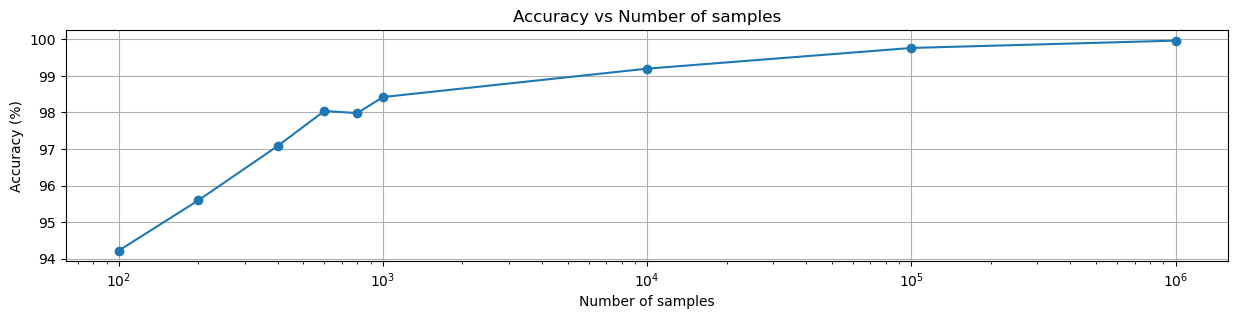

In [27]:
samples_list = [100, 200, 400, 600, 800, 1000, 10000, 100000, 1000000]
fig, ax1 = plt.subplots(1, 1, figsize=(15, 3))
    
# Plot accuracy
actual_pi = np.pi
accuracies = []
for n in samples_list:
    pi_estimate, _, _, _ = monte_carlo_pi(n)
    accuracy = 100 * (1 - abs(pi_estimate - actual_pi) / actual_pi) # 计算估计的pi值和真值之间的差异
    accuracies.append(accuracy)

ax1.plot(samples_list, accuracies, marker='o')
ax1.set_xscale('log')
ax1.set_xlabel('Number of samples')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy vs Number of samples')
ax1.grid(True)

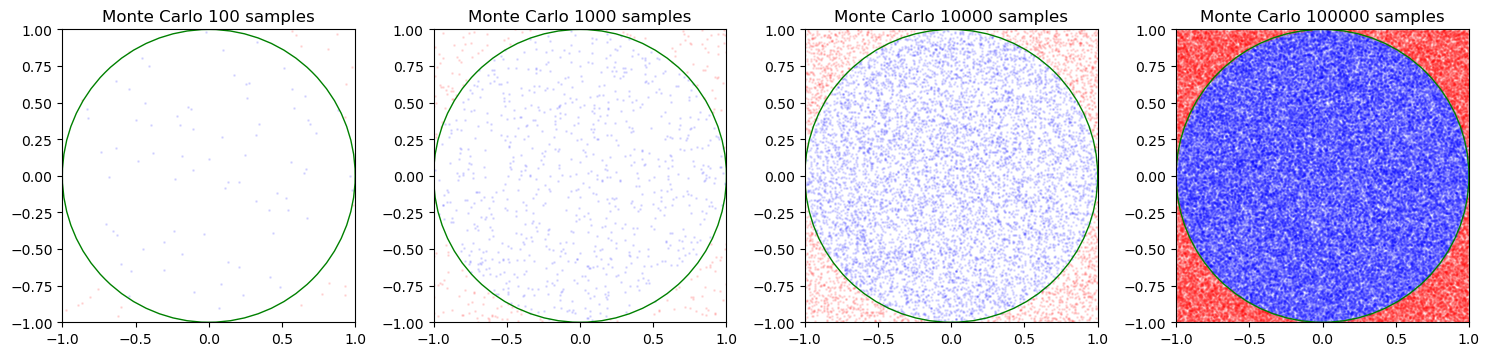

In [25]:

# Plot scatter for the last sample
fig, ax_list = plt.subplots(1, 4, figsize=(15, 6))

samples_list = [100, 1000, 10000, 100000]

for i in range(len(samples_list)):
    n = samples_list[i]
    _, x, y, inside_circle = monte_carlo_pi(n)
    
    ax_list[i].scatter(x[inside_circle], y[inside_circle], c='blue', alpha=0.1, s=1)
    ax_list[i].scatter(x[~inside_circle], y[~inside_circle], c='red', alpha=0.1, s=1)
    ax_list[i].set_aspect('equal', 'box')
    ax_list[i].set_xlim(-1, 1)
    ax_list[i].set_ylim(-1, 1)
    circle = plt.Circle((0, 0), 1, fill=False, color='green')
    ax_list[i].add_artist(circle)
    ax_list[i].set_title(f'Monte Carlo {n} samples')

plt.tight_layout()
plt.show()